In [1]:
import torch
from torch import nn
import wandb

networks = [nn.Linear(384, 32) for _ in range(8)]
wandb.init()
weight_artifact = wandb.use_artifact("yoshi-0921/LangStrat-exp/770w6wkd.pth:v11", type="pretrained_weight")
weight_artifact_dir = weight_artifact.download()
for agent_id, network in enumerate(networks):
    state_dict = torch.load(weight_artifact_dir + f"/agent{agent_id}.pth", map_location="cpu")
    fc_pth = {k.replace("fc0.",""):state_dict[k] for k in ["fc0.weight","fc0.bias"]}
    network.load_state_dict(fc_pth)


Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yoshi-0921 (use `wandb login --relogin` to force relogin)
wandb: wandb version 0.27.0 is available!  To upgrade, please run:
wandb:  $ pip install wandb --upgrade


In [2]:
root_dir = "/home/motokawa/projects/MAEXP/configs/experiments/LangStrat/tensors/"
type0_right_tensor = torch.load(root_dir + "type0_right_tensor")
type0_left_tensor = torch.load(root_dir + "type0_left_tensor")
type0_top_tensor = torch.load(root_dir + "type0_top_tensor")
type0_bottom_tensor = torch.load(root_dir + "type0_bottom_tensor")
type1_right_tensor = torch.load(root_dir + "type1_right_tensor")
type1_left_tensor = torch.load(root_dir + "type1_left_tensor")
type1_top_tensor = torch.load(root_dir + "type1_top_tensor")
type1_bottom_tensor = torch.load(root_dir + "type1_bottom_tensor")
unseen_type0_right_tensor = torch.load(root_dir + "unseen_type0_right_tensor")
unseen_type0_left_tensor = torch.load(root_dir + "unseen_type0_left_tensor")
unseen_type0_top_tensor = torch.load(root_dir + "unseen_type0_top_tensor")
unseen_type0_bottom_tensor = torch.load(root_dir + "unseen_type0_bottom_tensor")
unseen_type1_right_tensor = torch.load(root_dir + "unseen_type1_right_tensor")
unseen_type1_left_tensor = torch.load(root_dir + "unseen_type1_left_tensor")
unseen_type1_top_tensor = torch.load(root_dir + "unseen_type1_top_tensor")
unseen_type1_bottom_tensor = torch.load(root_dir + "unseen_type1_bottom_tensor")

<AxesSubplot:>

<Figure size 1000x2000 with 0 Axes>

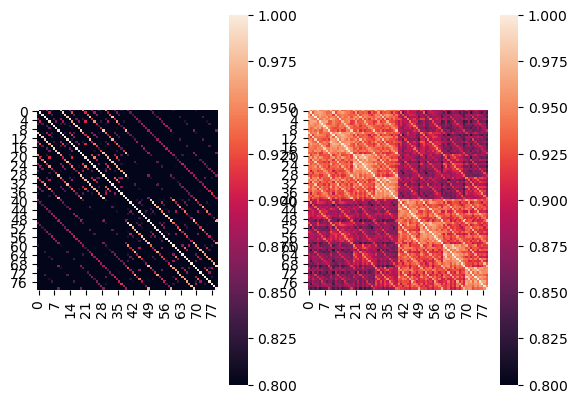

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

embeddings = torch.concat([type0_right_tensor,type0_left_tensor,type0_top_tensor,type0_bottom_tensor,type1_right_tensor,type1_left_tensor,type1_top_tensor,type1_bottom_tensor])
trained_embeddings = networks[0](torch.concat([type0_right_tensor,type0_left_tensor,type0_top_tensor,type0_bottom_tensor,type1_right_tensor,type1_left_tensor,type1_top_tensor,type1_bottom_tensor]))

final = []
for i in range(len(embeddings)):
    ans = []
    for j in range(len(embeddings)):
        similarity = torch.cosine_similarity(embeddings[i].view(1,-1),embeddings[j].view(1,-1)).item()
        ans.append(similarity)
    final.append(ans)

trained_final = []
for i in range(len(trained_embeddings)):
    ans = []
    for j in range(len(trained_embeddings)):
        similarity = torch.cosine_similarity(trained_embeddings[i].view(1,-1),trained_embeddings[j].view(1,-1)).item()
        ans.append(similarity)
    trained_final.append(ans)


plt.figure(figsize=(10, 20)) 

fig = plt.figure()
plt.subplot(1, 2, 1)
sns.heatmap(
    final,
    square=True,
    annot=False,
    vmin=0.8)
plt.subplot(1, 2, 2)
sns.heatmap(trained_final,
    square=True,
    annot=False,
    vmin=0.8)


<AxesSubplot:>

<Figure size 1000x2000 with 0 Axes>

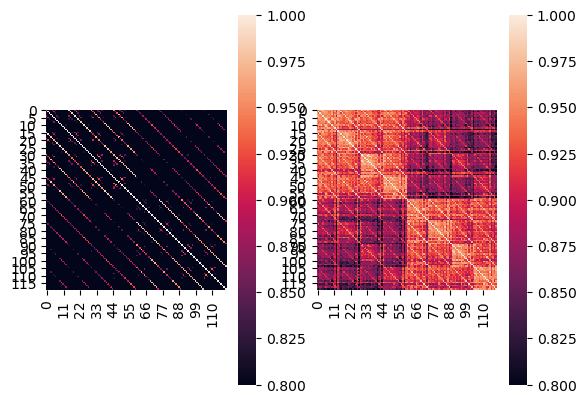

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

embeddings = torch.concat([type0_right_tensor,unseen_type0_right_tensor,type0_left_tensor,unseen_type0_left_tensor,type0_top_tensor,unseen_type0_top_tensor,type0_bottom_tensor,unseen_type0_bottom_tensor,type1_right_tensor,unseen_type1_right_tensor,type1_left_tensor,unseen_type1_left_tensor,type1_top_tensor,unseen_type1_top_tensor,type1_bottom_tensor,unseen_type1_bottom_tensor])

trained_embeddings = networks[0](embeddings)

final = []
for i in range(len(embeddings)):
    ans = []
    for j in range(len(embeddings)):
        similarity = torch.cosine_similarity(embeddings[i].view(1,-1),embeddings[j].view(1,-1)).item()
        ans.append(similarity)
    final.append(ans)

trained_final = []
for i in range(len(trained_embeddings)):
    ans = []
    for j in range(len(trained_embeddings)):
        similarity = torch.cosine_similarity(trained_embeddings[i].view(1,-1),trained_embeddings[j].view(1,-1)).item()
        ans.append(similarity)
    trained_final.append(ans)


plt.figure(figsize=(10, 20)) 

fig = plt.figure()
plt.subplot(1, 2, 1)
sns.heatmap(
    final,
    square=True,
    annot=False,
    vmin=0.8)
plt.subplot(1, 2, 2)
sns.heatmap(trained_final,
    square=True,
    annot=False,
    vmin=0.8)


<AxesSubplot:>

<Figure size 1000x2000 with 0 Axes>

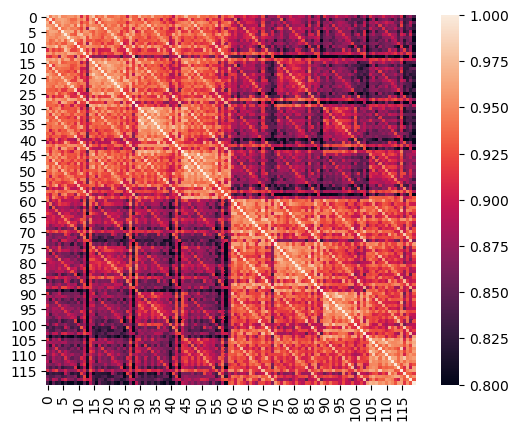

In [5]:
plt.figure(figsize=(10, 20)) 
fig = plt.figure()
sns.heatmap(trained_final,
    square=True,
    annot=False,
    vmin=0.8)

In [10]:
type0_right_tensor.std()

tensor(0.0510)